# Stochastic Scheduling and MDPs

In [1]:
from importlib.util import find_spec

if not all(find_spec(pkg) for pkg in ['aalpy', 'pm4py', 'pygraphviz']):
  !apt install libgraphviz-dev
  !pip install aalpy pm4py pygraphviz

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libgail-common libgail18 libgtk2.0-0 libgtk2.0-bin libgtk2.0-common libgvc6-plugins-gtk
  librsvg2-common libxdot4
Suggested packages:
  gvfs
The following NEW packages will be installed:
  libgail-common libgail18 libgraphviz-dev libgtk2.0-0 libgtk2.0-bin libgtk2.0-common
  libgvc6-plugins-gtk librsvg2-common libxdot4
0 upgraded, 9 newly installed, 0 to remove and 49 not upgraded.
Need to get 2,434 kB of archives.
After this operation, 7,681 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libgtk2.0-common all 2.24.33-2ubuntu2.1 [125 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libgtk2.0-0 amd64 2.24.33-2ubuntu2.1 [2,038 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libgail18 amd64 2.24.33-2ubuntu2.1 [15.9 kB]
Get:4 http://archive.ubun

## Stochastic Schedule Example Design

In [2]:
tasks = [1, 2, 3]
constraints = [
    (1, "e", 2, "b", [0, 5]),
    (2, "b", 3, "b", [2, 5])
]
durations = {1: (1, 4), 2: (2, 4), 3: (1, 2)}
probabilities = {1: [0.2, 0.3, 0.4, 0.1], 2: [0.3, 0.3, 0.3], 3: [0.9, 0.1]}

## Stochastic System Implementation

In [3]:
from aalpy.base import SUL
from random import choices

class ScheduleSUL(SUL):
    def __init__(self, tasks, constraints, durations, probabilities):
        super().__init__()
        self.tasks = tasks
        self.constraints = constraints
        self.durations = durations
        self.probabilities = probabilities
        self.plan = {}
        self.current_time = 0

    def pre(self):
        self.plan = {}
        self.current_time = 0

    def post(self):
        self.plan = {}
        self.current_time = 0

    def step(self, task):
        if task is None:
          return 0

        if self._inconsistent():
            return "fail"

        if set(self.plan.keys()) == set(self.tasks):
            return "success"

        if task not in self.plan:
            duration = choices(
                range(self.durations[task][0], self.durations[task][1] + 1),
                weights=self.probabilities[task]
            )[0]
            self.plan[task] = (self.current_time, self.current_time + duration)

            if self._inconsistent():
                return "fail"
            if set(self.plan.keys()) == set(self.tasks):
                return "success"
            self.current_time += 1
            return 0

        if task in self.plan:
            if self.current_time >= self.plan[task][1]:
                self.current_time += 1
                return 1
            self.current_time += 1
            return 0

    def _inconsistent(self):
        for constraint in self.constraints:
            t1, op1, t2, op2, interval = constraint
            if t1 in self.plan and t2 in self.plan:
                time_diff = (
                    (self.plan[t2][0] if op2 == "b" else self.plan[t2][1])
                    - (self.plan[t1][0] if op1 == "b" else self.plan[t1][1])
                )
                if not (interval[0] <= time_diff <= interval[1]):
                    return True
        return False

## MDP Extraction via Automata Learning

In [4]:
sul = ScheduleSUL(tasks, constraints, durations, probabilities)

In [5]:
from aalpy.oracles import RandomWalkEqOracle
eq_oracle = RandomWalkEqOracle(tasks, sul)

from aalpy.learning_algs import run_stochastic_Lstar
learned_mdp = run_stochastic_Lstar(tasks, sul, eq_oracle)

Hypothesis: 1: 1 states.
Hypothesis: 2: 7 states.
Hypothesis: 3: 9 states.
Hypothesis: 4: 12 states.
Hypothesis: 5: 15 states.
Hypothesis: 6: 17 states.
Hypothesis: 7: 21 states.
Hypothesis: 8: 22 states.
Hypothesis: 9: 23 states.
Hypothesis: 10: 22 states.
Hypothesis: 11: 25 states.
Hypothesis: 12: 29 states.
Hypothesis: 13: 29 states.
Hypothesis: 14: 29 states.
Hypothesis: 15: 29 states.
Hypothesis: 16: 29 states.
Hypothesis: 17: 29 states.
Hypothesis: 18: 29 states.
Hypothesis: 19: 29 states.
Hypothesis: 20: 28 states.
Hypothesis: 21: 28 states.
Hypothesis: 22: 28 states.
Hypothesis: 23: 28 states.
Hypothesis: 24: 28 states.
Hypothesis: 25: 28 states.
Unambiguous rows: 90.74%; 98 out of 108
Hypothesis: 26: 28 states.
Hypothesis: 27: 28 states.
Hypothesis: 28: 29 states.
Hypothesis: 29: 29 states.
Hypothesis: 30: 29 states.
Unambiguous rows: 85.71%; 96 out of 112
Hypothesis: 31: 29 states.
Hypothesis: 32: 29 states.
Hypothesis: 33: 29 states.
Hypothesis: 34: 29 states.
Hypothesis: 35

Visualization started in the background thread.
Visualizing 30 state automaton could take some time.
Model saved to LearnedModel.svg.


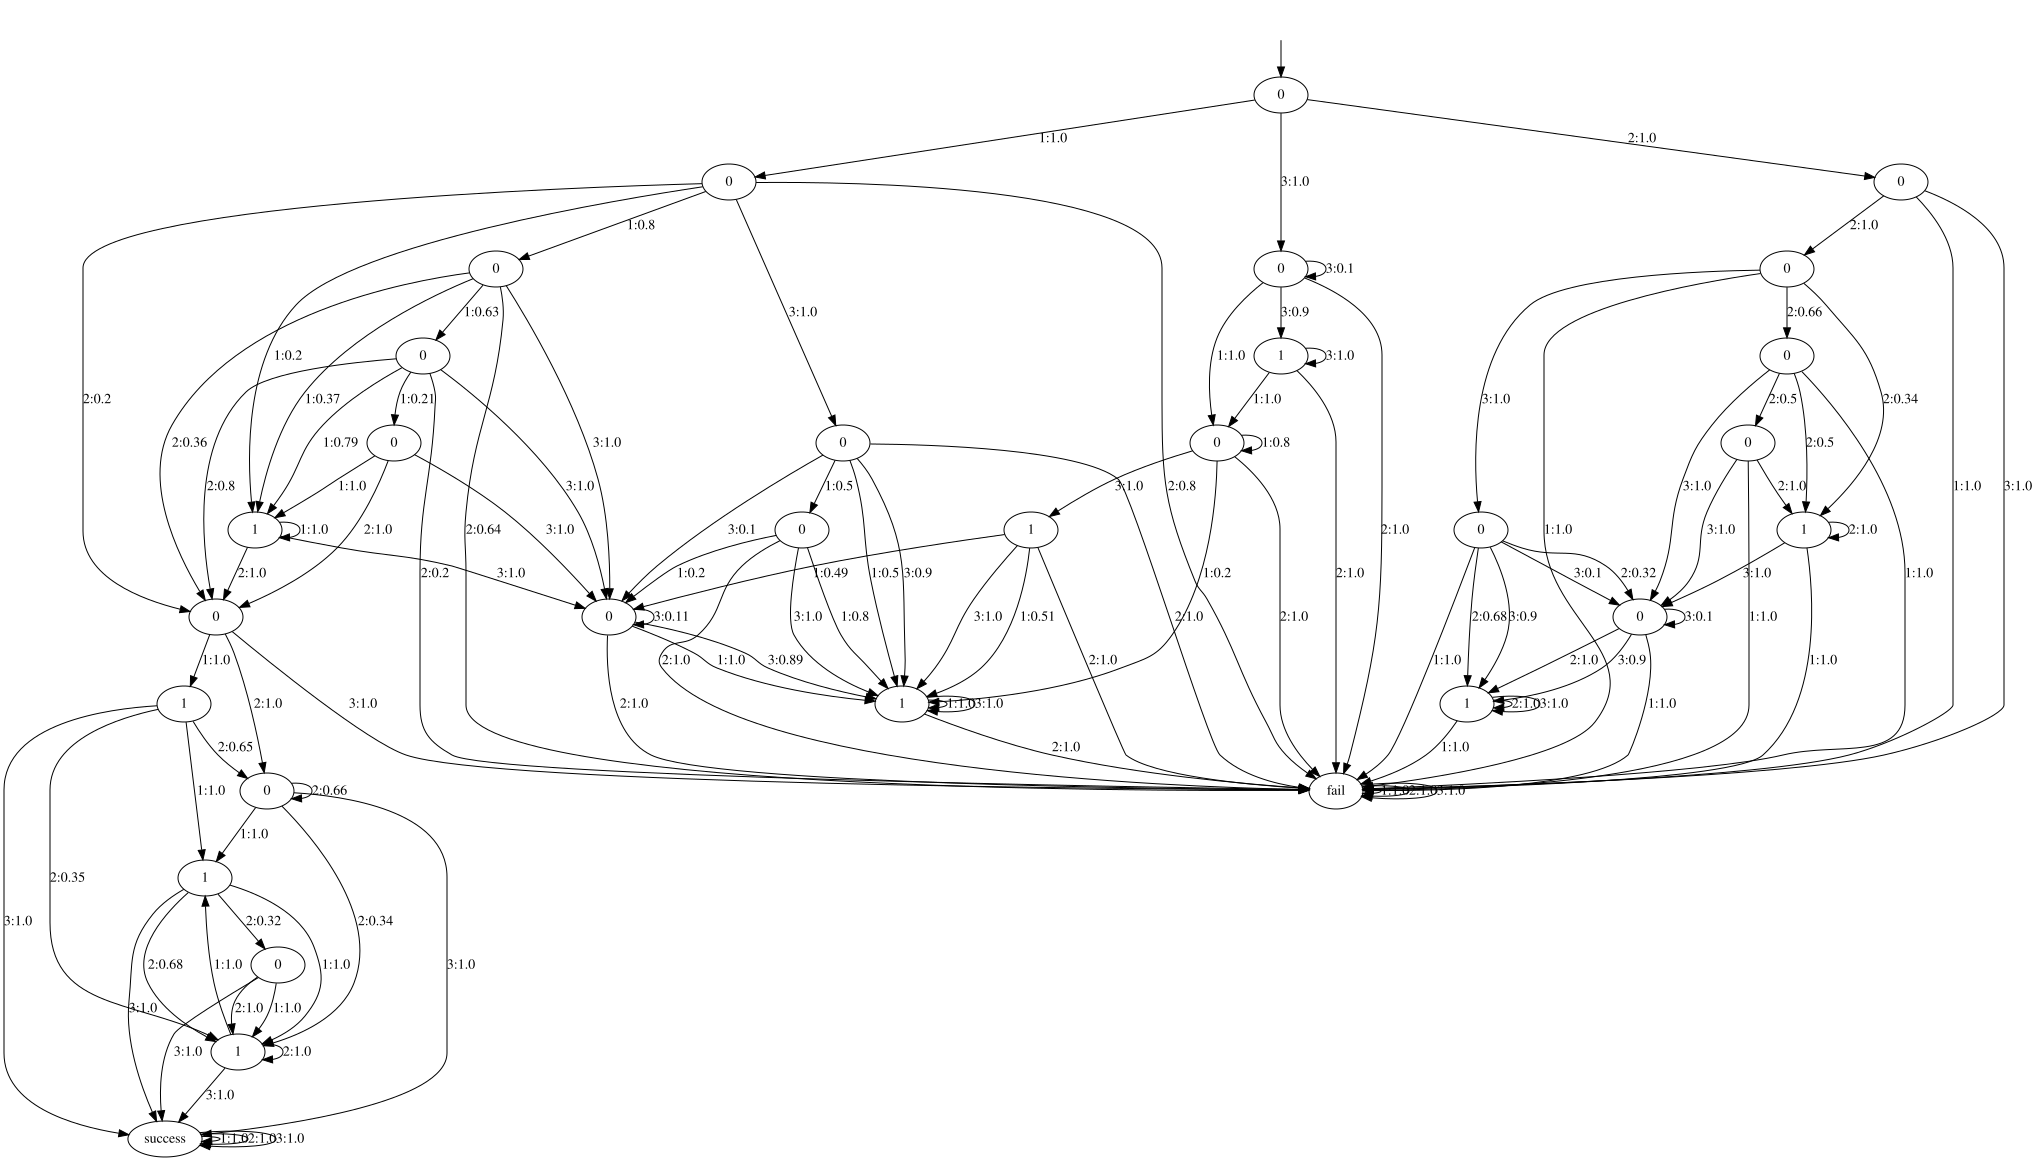

In [6]:
from IPython.display import SVG
import time

learned_mdp.visualize(file_type='svg')

time.sleep(1) # ugly workaround
display(SVG('LearnedModel.svg'))

## Fair Strategy Implementation

In [7]:
from aalpy.utils import save_automaton_to_file

save_automaton_to_file(learned_mdp, file_type="dot")
time.sleep(1)

Model saved to LearnedModel.dot.


In [8]:
from random import choices
import networkx as nx

graph = nx.nx_pydot.read_dot("LearnedModel.dot")
graph.remove_node("__start0")

for u, v, attributes in graph.edges(data=True):
        edge_label = attributes.get('label')

        action, probability = edge_label[1:-1].split(':')
        attributes['action'] = action.strip()
        attributes['probability'] = float(probability.strip())

In [9]:
# Find source and target nodes
initial_state = "s0"
success_state = None

for node_id, attributes in graph.nodes(data=True):
    if attributes.get('label') == "\"success\"":
        success_state = node_id

# Find the shortest path from initial_state to success_state
shortest_path = nx.shortest_path(graph, source=initial_state, target=success_state)

shortest_path

['s0', 's1', 's12', 's16', 's28']

In [10]:
def phi(source):
    """
    Strategy function determining the next action based on the shortest path.

    Args:
        source (node): Current state/node in the graph.

    Returns:
        action: Action to take based on the shortest path or random choice.
    """
    if source in shortest_path:
        # Get the index of the current node in the shortest path
        idx = shortest_path.index(source)
        # Find the next node on the shortest path
        next_node = shortest_path[idx + 1]
        # Return the action on the edge between source and next_node
        return graph[source][next_node][0]['action']

    # If source is not in the shortest path, choose the most likely action
    return sorted(graph.out_edges([source], data=True), key=('probability', 'action'))[-1]['action']

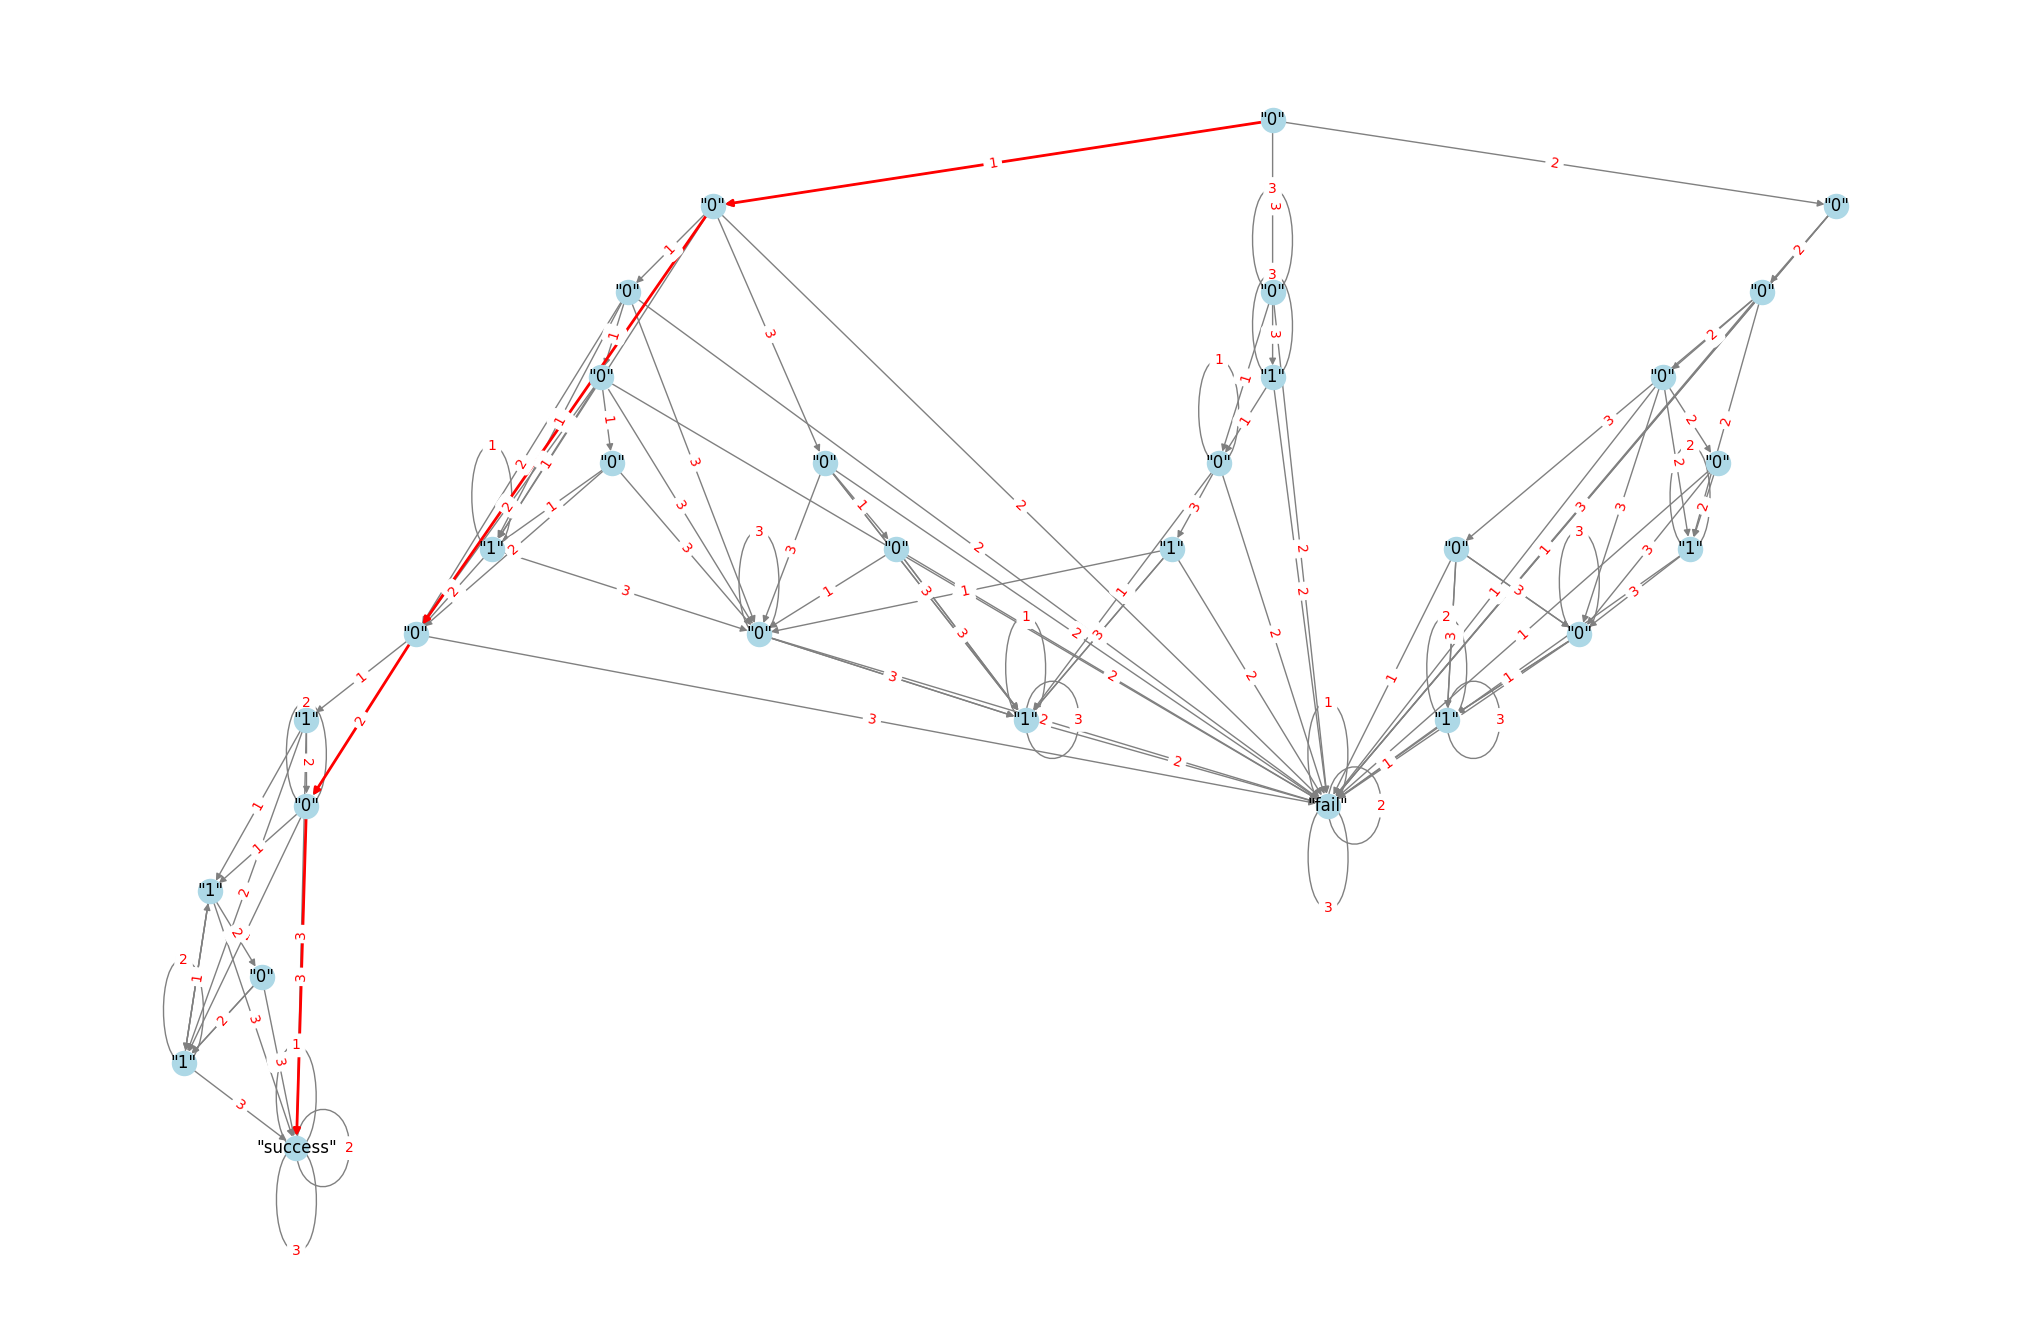

In [11]:
import matplotlib.pyplot as plt


pos = nx.nx_agraph.pygraphviz_layout(graph, prog="dot")
plt.figure(figsize=(20, 13))

node_labels = nx.get_node_attributes(graph, "label")
nx.draw(graph, pos, labels=node_labels, node_color="lightblue", edge_color="gray")

best_path_edges = list(zip(shortest_path[:-1], shortest_path[1:]))
nx.draw_networkx_edges(graph, pos, edgelist=best_path_edges, edge_color="red", width=2)

edge_labels = nx.get_edge_attributes(graph, "action")
nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels, font_color="red", font_size=10)

plt.show()

## Trace Generation

In [12]:
from random import choices

def generate_trace(graph, phi):
    current = 's0'  # Initial state stored in graph metadata
    trace = [graph.nodes[current]["label"]]  # Start with the label of the initial state

    while graph.nodes[current]["label"] not in {"\"success\"", "\"fail\""}:
        action = phi(current)  # Get the action from the positional strategy
        trace.append(action)  # Append the action to the trace

        # Gather all outgoing edges with the given action
        edges = [(v, d) for u, v, d in graph.out_edges([current], data=True) if d["action"] == action]

        if not edges:
            raise ValueError(f"No outgoing edges with action '{action}' from state {current}.")

        # Determine the next state based on transition probabilities
        targets, probabilities = zip(*[(v, d["probability"]) for v, d in edges])
        next_state = choices(targets, weights=probabilities)[0]

        current = next_state
        trace.append(graph.nodes[current]["label"])  # Append the label of the new state

    return trace

# Generate multiple traces
traces = [generate_trace(graph, phi) for _ in range(1000)]

traces[:10]

[['"0"', '1', '"0"', '2', '"fail"'],
 ['"0"', '1', '"0"', '2', '"0"', '2', '"0"', '3', '"success"'],
 ['"0"', '1', '"0"', '2', '"fail"'],
 ['"0"', '1', '"0"', '2', '"fail"'],
 ['"0"', '1', '"0"', '2', '"fail"'],
 ['"0"', '1', '"0"', '2', '"0"', '2', '"0"', '3', '"success"'],
 ['"0"', '1', '"0"', '2', '"fail"'],
 ['"0"', '1', '"0"', '2', '"fail"'],
 ['"0"', '1', '"0"', '2', '"fail"'],
 ['"0"', '1', '"0"', '2', '"fail"']]

## BPMN Mining

In [13]:
import pm4py
from pm4py.objects.log.obj import EventLog, Trace, Event

# Create an EventLog object
event_log = EventLog()

# Populate the EventLog with traces
for trace in traces:
    pm4py_trace = Trace()
    for idx, activity in enumerate(trace):
        event = Event({
            'concept:name': activity,  # Activity name
            'time:timestamp': idx      # Add a dummy timestamp
        })
        pm4py_trace.append(event)
    event_log.append(pm4py_trace)

/usr/local/lib/python3.11/dist-packages/cudf/utils/_ptxcompiler.py:64: UserWarning: Error getting driver and runtime versions:

stdout:



stderr:

Traceback (most recent call last):
  File "<string>", line 4, in <module>
  File "/usr/local/lib/python3.11/dist-packages/numba/cuda/cudadrv/driver.py", line 295, in __getattr__
    raise CudaSupportError("Error at driver init: \n%s:" %
numba.cuda.cudadrv.error.CudaSupportError: Error at driver init: 

CUDA driver library cannot be found.
If you are sure that a CUDA driver is installed,
try setting environment variable NUMBA_CUDA_DRIVER
with the file path of the CUDA driver shared library.
:


Not patching Numba
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.11/dist-packages/cudf/utils/gpu_utils.py:62: UserWarning: Failed to dlopen libcuda.so.1
  warnings.warn(str(e))


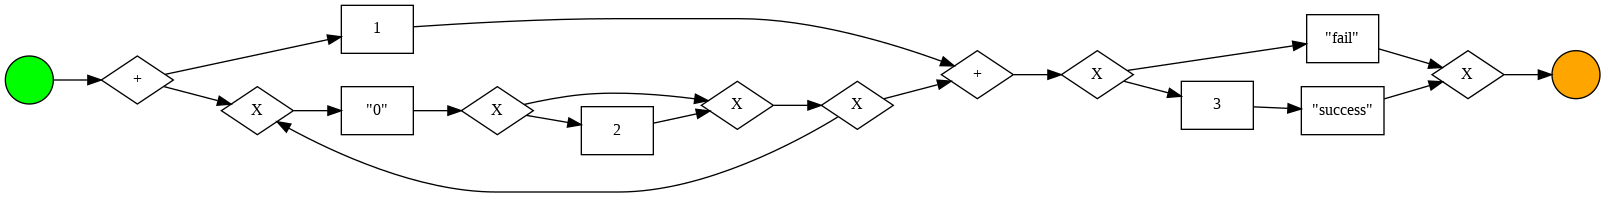

In [14]:
# Apply BPMN discovery algorithm
process_tree = pm4py.discover_process_tree_inductive(event_log)

# Visualize the BPMN model
bpmn_model = pm4py.convert_to_bpmn(process_tree)
pm4py.view_bpmn(bpmn_model)